In [1]:
import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from model.classifier import Classifier, MyProgressBar

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from its.transform import multi_transform
from utils.affine_transforms import AffineTransformation2D
from dataset.mnist_no_pil import NoPILMNIST, NoPILFashionMNIST, AffineTransformDataset

dataset = 'mnist' # or 'fmnist'
batch_size = 128
#divide by 255 transform


if dataset == 'mnist':
    # essentially excluding either 6 or 9 as these would cause degenerations under 180 degree rotation
    dataset_train = NoPILMNIST("../experiment_files/data",train=True,download=True)
    n_classes = 10
    dataset_val_test = NoPILMNIST("../experiment_files/data",train=False,download=True)
    #split into validation and test set
    dataset_val, dataset_test_pre = #fix this, use val from train as this is what is usually expected.
elif dataset == 'fmnist':
    dataset_train = NoPILFashionMNIST("../experiment_files/data",train=True,download=True)
    n_classes = 10
    dataset_val_test = NoPILFashionMNIST("../experiment_files/data",train=False,download=True)
    #split into validation and test set
    dataset_val, dataset_test_pre = #fix this, use val from train as this is what is usually expected.



transformations = [AffineTransformation2D.ROTATION.value,AffineTransformation2D.SHEARING_X.value,AffineTransformation2D.SHEARING_Y.value
                     ,AffineTransformation2D.SCALING_X.value,AffineTransformation2D.SCALING_Y.value]
domains = [(-torch.pi,torch.pi), ((-0.5, 0.5),), ((-0.5, 0.5),), ((1/1.3-1, 0.3),), ((1/1.3-1, 0.3),)]
n_samples = 17

def transform(batch_size):
    n = torch.randint(0, n_samples, (batch_size, len(transformations)), device="cpu")
    x_test = torch.zeros(batch_size, 1, 28, 28, device="cpu")
    _, _, T = multi_transform(x_test, transformations, n, n_samples=n_samples, domain=domains)
    return T


dataset_test = AffineTransformDataset(dataset_test_pre,transform,return_transformation=False,batch_size=batch_size)


In [3]:
train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True, num_workers=4,persistent_workers=True)
val_loader = torch.utils.data.DataLoader(dataset_val, batch_size=batch_size, shuffle=False, num_workers=4,persistent_workers=True)
test_loader = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=False, num_workers=4,persistent_workers=True)

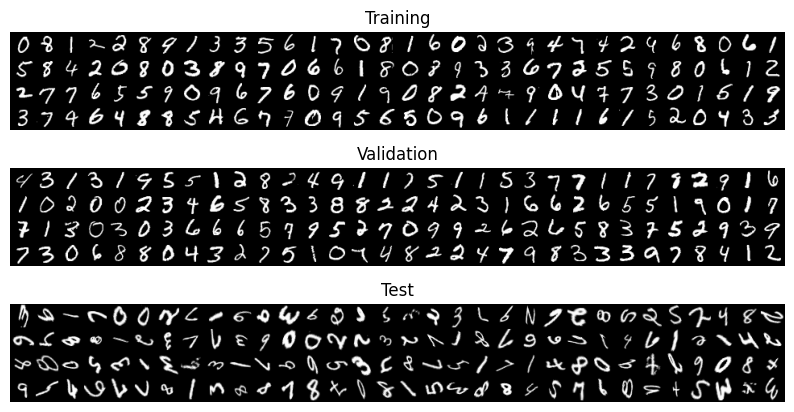

In [4]:
#test images
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10, 5))

axs[0].imshow(torchvision.utils.make_grid(next(iter(train_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[1].imshow(torchvision.utils.make_grid(next(iter(val_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[2].imshow(torchvision.utils.make_grid(next(iter(test_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[0].set_title('Training')
axs[1].set_title('Validation')
axs[2].set_title('Test')

for ax in axs.flat:
    ax.axis('off')

In [5]:
import pytorch_lightning as pl
import os

model_path = f'../model/{dataset}_uncertainty.pth'

model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 32x14x14
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x7x7
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 256),
    nn.Dropout(0.5),
    nn.ReLU(),
    nn.Linear(256, 10)
)


# Check if model is already trained
if os.path.exists(model_path):
    print(f"Loading model from {model_path}")
    model.load_state_dict(torch.load(model_path))
else:
    print(f"Training model and will save to {model_path}")
    lightning_model = Classifier(model, optimizer_class =  torch.optim.AdamW, optimizer_params = {"lr": 1e-3})
    progress_bar = MyProgressBar()
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=10,
        precision="16-mixed",
        callbacks=[progress_bar],
    )
    # Train the model
    trainer.fit(lightning_model, train_loader,val_loader)
    # Test the model
    #trainer.test(lightning_model, test_loader)
    # Save model
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")

Loading model from ../model/mnist_uncertainty.pth


In [6]:
#calibrate the model
#from confidence.calibration import TemperatureCalibrationModule
#if model is not temperature calibrated
#if isinstance(model, TemperatureCalibrationModule):
    #model = model.model
#model = TemperatureCalibrationModule(model,per_logit=True).cuda()
#model.fit(test_loader)


In [7]:
model.cuda()

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Flatten(start_dim=1, end_dim=-1)
  (9): Linear(in_features=3136, out_features=256, bias=True)
  (10): Dropout(p=0.5, inplace=False)
  (11): ReLU()
  (12): Linear(in_features=256, out_features=10, bias=True)
)

In [8]:
with torch.no_grad():
    model.eval()
    test_acc = 0
    for data, target in val_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_val)
    print(f'Mean accuracy on the val set: {test_acc}.')

Mean accuracy on the val set: 0.992.


In [9]:
with torch.no_grad():
    model.eval()
    test_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_test)
    print(f'Mean accuracy on the transformed test set: {test_acc}.')

Mean accuracy on the transformed test set: 0.3882.


In [10]:
from confidence.utils import ModelInputWrapper

#use model wrapper to extract the embeddings
dual_ouput_model = ModelInputWrapper(model,'9',flatten=True)

In [11]:
#extract embeddings and fit NNDistanceConfidence()
embeddings=[]
classes =[]
for batch in train_loader:
    emb,_ = dual_ouput_model(batch[0].cuda())
    embeddings.append(emb.detach().cpu().numpy())
    classes.append(batch[1].detach().cpu().numpy())


embeddings = np.vstack(embeddings)
classes = np.hstack(classes)

#randomly sample 5000 ones
if embeddings.shape[0] > 5000:
    indices = np.random.choice(embeddings.shape[0], 5000, replace=False)
    embeddings = embeddings[indices]

In [12]:
from utils.transform_sequence import TransformSequence

transform_seq =TransformSequence(transformations, domains,device=device)

In [13]:
from utils.transformation_problem import TransformationProblem
from confidence.base_confidence import SplitConfidence, SinglePassConfidence, EnergyConfidence


In [14]:
conf_simple = SinglePassConfidence(model,EnergyConfidence())

In [15]:
problem1 = TransformationProblem(conf_simple, transform_seq, consolidate_method="consolidate_simple")

In [16]:

from confidence.nn import NNDistanceConfidence
#test nearrest neigbhoor confidence
nearest_neighbor_confidence = NNDistanceConfidence(index_type="ivfpq",number_of_neighbors=3)
nearest_neighbor_confidence.fit(embeddings)
nearest_neighbor_confidence.cuda()

NNDistanceConfidence()

In [17]:


conf_split = SplitConfidence(nearest_neighbor_confidence,EnergyConfidence(), mult=True,b=1.0)
conf_2 = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem2 = TransformationProblem(conf_2, transform_seq, consolidate_method="consolidate_simple")


In [18]:
import search.shgo
import importlib
importlib.reload(search.shgo)

<module 'search.shgo' from 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\search\\shgo.py'>

In [19]:
di = search.shgo.SHGO(selection_method="topk")

In [20]:
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem1, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem1.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.8104.


In [21]:
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem2, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem2.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.8902.


In [22]:
from confidence.model.mc_droupout import MonteCarloDropoutConfidence, MutualInformationCriterion


conf_monte_carlo = MonteCarloDropoutConfidence(model,MutualInformationCriterion(),samples=8,data_dims=3,parallel=False,average=False)

In [23]:
conf_monte_carlo(torch.randn(2, 1, 28, 28).cuda())

(tensor([0.5013, 0.8358], device='cuda:0', grad_fn=<RsubBackward1>),
 tensor([[[-28.1932,  -1.4482, -38.5108, -16.8533, -12.2664,  25.9193, -34.0907,
            11.2011, -40.8735,  -8.2193],
          [-26.7382,  41.0194, -35.6419, -19.2663, -25.4063,  17.9806, -28.2642,
            32.3089, -76.8781, -42.9437],
          [-60.0141,  15.8812, -35.8008, -24.7683, -11.4087,   9.9253, -55.3848,
            35.2361, -87.0352, -10.9861],
          [-44.6504,  23.4915, -17.0070, -25.8047,  25.1267, -23.1654, -42.4201,
            20.1767, -38.1605,   1.7403],
          [-60.7433,  38.7152, -44.0532, -25.9927,  -8.8551,   6.0741, -28.9395,
            25.0164, -73.1992, -35.2296],
          [-20.5249,  19.6785, -41.8148, -26.9368, -16.1334,  32.4363, -17.4725,
             6.5581, -51.1300, -26.1854],
          [-50.1466,  -7.6662, -10.4475, -13.0859, -19.2920,  27.4479, -41.0473,
            24.5819, -66.7160, -17.3959],
          [-43.4755,  15.6003, -19.0828, -29.7409,   9.9467,   4.9981,

In [24]:
problem3 = TransformationProblem(conf_monte_carlo, transform_seq, consolidate_method="consolidate_simple")

In [25]:
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem3, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem3.transform(data.cuda().contiguous(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.8092.


In [26]:
#using torch uncertainty monte carlo dropout

from torch_uncertainty.post_processing import LaplaceApprox

In [27]:
#deepcopy the model

model2 =torch.nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 32x14x14
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x7x7
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 256),
    nn.Dropout(0.5),
    nn.ReLU(),
    nn.Linear(256, 10)
).cuda()
model2.load_state_dict(model.state_dict())

<All keys matched successfully>

In [80]:
lap = LaplaceApprox(task='classification',model=model2,link_approx="mc")

In [81]:
lap.fit(train_loader)

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\laplace\baselaplace.py:435: UserWarning: By default `link_approx` is `probit`. Make sure to set it equals to the way you want to call `la(test_data, pred_type=..., link_approx=...)`.
  warnings.warn(


In [82]:
di2 = search.shgo.SHGO(selection_method="topk",local_max_steps=0)

In [83]:
lap(torch.randn(2, 1, 28, 28).cuda()).cpu().numpy().shape

(2, 10)

In [84]:
conf_laplace = SinglePassConfidence(lap,EnergyConfidence())
problem4 = TransformationProblem(conf_laplace, transform_seq, consolidate_method="consolidate_simple")


In [85]:
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di2.optimize(problem4, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem4.transform(data.cuda().contiguous(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.8108.


In [ ]:
#pred types nn glm
#link aprox types are probit,mc, bridge, bride_norm

In [78]:
lap.la(torch.randn(2, 1, 28, 28).cuda(),link_approx ="mc",pred_type="nn",n_samples=2000).shape

KeyboardInterrupt: 

In [92]:
lap.la._glm_predictive_distribution(torch.randn(1, 1, 28, 28).cuda())[1].shape

torch.Size([1, 10, 10])

In [67]:
lap.la.sample(20000).shape

torch.Size([20000, 2570])

In [34]:
#now try torch uncertainty monte carlo batch norm

In [35]:
from torch_uncertainty.post_processing import MCBatchNorm

model_batch_normed = MCBatchNorm(model2, num_estimators=8, convert=True, mc_batch_size=32)

In [36]:
conf_monte_carlo_bn = SinglePassConfidence(model_batch_normed,EnergyConfidence())
problem5 = TransformationProblem(conf_monte_carlo_bn, transform_seq, consolidate_method="consolidate_simple")


In [37]:
model_batch_normed.cpu()

MCBatchNorm(
  (model): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): MCBatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): MCBatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=3136, out_features=256, bias=True)
    (10): Dropout(p=0.5, inplace=False)
    (11): ReLU()
    (12): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [38]:
model_batch_normed.fit(train_loader)

In [39]:
model_batch_normed.eval().cuda()

MCBatchNorm(
  (model): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): MCBatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): MCBatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=3136, out_features=256, bias=True)
    (10): Dropout(p=0.5, inplace=False)
    (11): ReLU()
    (12): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [40]:
model_batch_normed(torch.randn(2, 1, 28, 28).cuda()).shape

torch.Size([16, 10])